<a href="https://www.kaggle.com/code/minhtuan11/it2058-da?scriptVersionId=352586227" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [9]:
import os
import random
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

SEED = 42
seed_everything(SEED)

#### SỬ dụng tỉ lệ của tập datashet 50 25 25

In [2]:
# import os
# import pandas as pd

# # Đường dẫn gốc chứa 3 thư mục: train, valid, test
# base_dir = '/kaggle/input/datasets/minhtuan11/fetal-echocardiography-first-trimester/Fetal Echocardiography First Trimester'

# def load_data_from_folder(split_name):
#     folder_path = os.path.join(base_dir, split_name)
#     filepaths, labels = [], []
    
#     for root, dirs, files in os.walk(folder_path):
#         for file in files:
#             if file.lower().endswith(('.png', '.jpg', '.jpeg')):
#                 filepaths.append(os.path.join(root, file))
#                 labels.append(os.path.basename(root))
                
#     return pd.DataFrame({'filepath': filepaths, 'label': labels})

# # 1. Đọc trực tiếp từ các thư mục có sẵn
# train_df = load_data_from_folder('train')
# val_df   = load_data_from_folder('valid')
# test_df  = load_data_from_folder('test')

# # 2. Ánh xạ nhãn sang dạng số
# label_to_idx = {label: idx for idx, label in enumerate(train_df['label'].unique())}
# train_df['label_idx'] = train_df['label'].map(label_to_idx)
# val_df['label_idx']   = val_df['label'].map(label_to_idx)
# test_df['label_idx']  = test_df['label'].map(label_to_idx)

# # 3. Kiểm tra số lượng ảnh chính xác từ thư mục gốc
# print(f"Tập Train: {len(train_df)} ảnh")
# print(f"Tập Valid: {len(val_df)} ảnh")
# print(f"Tập Test:  {len(test_df)} ảnh\n")

# # Bảng tổng hợp chi tiết theo từng lớp
# split_summary = pd.DataFrame({
#     'Train': train_df['label'].value_counts(),
#     'Valid': val_df['label'].value_counts(),
#     'Test':  test_df['label'].value_counts()
# }).fillna(0).astype(int)

# print("--- Phân bố mẫu trong các thư mục gốc ---")
# print(split_summary)

#### Chia theo paper 60 20 20 

In [14]:
import os
import re
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

base_dir = '/kaggle/input/datasets/minhtuan11/fetal-echocardiography-first-trimester/Fetal Echocardiography First Trimester'

filepaths, labels, patient_ids = [], [], []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(root, file)
            
            # 1. Lấy tên lớp từ thư mục chứa file
            label = os.path.basename(root)
            
            # 2. Tách Mã Bệnh Nhân từ tên file (Ví dụ: "Flows test (137).png" -> "137")
            match = re.search(r"\((\d+)\)", file)
            patient_id = match.group(1) if match else os.path.splitext(file)[0]

            filepaths.append(full_path)
            labels.append(label)
            patient_ids.append(patient_id)

# Tạo DataFrame tổng
df = pd.DataFrame({
    'filepath': filepaths, 
    'label': labels, 
    'patient_id': patient_ids
})

# 3. TẠO CỘT 'label_idx' TRỰC TIẾP TRÊN DF GỐC (Tránh lỗi KeyError)
unique_labels = sorted(df['label'].unique())
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
df['label_idx'] = df['label'].map(label_to_idx)

# 4. TẠO BỘ BIẾN XUẤT RA CHO BLOCK TRAIN
num_classes = len(label_to_idx)
target_names = [label for label, _ in sorted(label_to_idx.items(), key=lambda x: x[1])]

# 5. CHIA TẬP THEO PATIENT-LEVEL (Train 60%, Valid 20%, Test 20%)
gss_train = GroupShuffleSplit(n_splits=1, test_size=0.40, random_state=42)
train_idx, temp_idx = next(gss_train.split(df, groups=df['patient_id']))

train_df = df.iloc[train_idx].copy().reset_index(drop=True)
temp_df  = df.iloc[temp_idx].copy().reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['patient_id']))

val_df  = temp_df.iloc[val_idx].copy().reset_index(drop=True)
test_df = temp_df.iloc[test_idx].copy().reset_index(drop=True)

print("=== HOÀN TẤT XỬ LÝ DỮ LIỆU (BLOCK 1) ===")
print(f"Tổng số ảnh: {len(df)}")
print(f"Danh sách các lớp ({num_classes} lớp): {target_names}")
print(f"Số lượng bệnh nhân thực tế: {df['patient_id'].nunique()}")
print(f"Phân bổ: Train={len(train_df)} | Valid={len(val_df)} | Test={len(test_df)} ảnh")
print(f"Các cột đã sẵn sàng: {list(train_df.columns)}")

=== HOÀN TẤT XỬ LÝ DỮ LIỆU (BLOCK 1) ===
Tổng số ảnh: 6720
Danh sách các lớp (5 lớp): ['Aorta', 'Flows', 'Other', 'V sign', 'X sign']
Số lượng bệnh nhân thực tế: 1490
Phân bổ: Train=4130 | Valid=1300 | Test=1290 ảnh
Các cột đã sẵn sàng: ['filepath', 'label', 'patient_id', 'label_idx']


In [4]:
!find '/kaggle/input/datasets/minhtuan11/fetal-echocardiography-first-trimester/Fetal Echocardiography First Trimester/test' -type f | wc -l

1380


Đang chạy trên thiết bị: cuda

Epoch    | Train Loss | Train Acc  | Val Loss   | Val Acc    | Val Macro F1 | Status
--------------------------------------------------------------------------------
01/15    | 0.2999     | 74.33    % | 0.1108     | 93.23    % | 0.9033       | [Saved Best]
02/15    | 0.0459     | 93.90    % | 0.0485     | 94.38    % | 0.9266       | [Saved Best]
03/15    | 0.0155     | 97.29    % | 0.0521     | 95.85    % | 0.9442       | [Saved Best]
04/15    | 0.0157     | 96.97    % | 0.0735     | 94.46    % | 0.9167       | Patience 1/4
05/15    | 0.0039     | 99.18    % | 0.0728     | 97.00    % | 0.9574       | [Saved Best]
06/15    | 0.0011     | 99.76    % | 0.0744     | 97.38    % | 0.9575       | [Saved Best]
07/15    | 0.0135     | 99.37    % | 0.3426     | 89.31    % | 0.8314       | Patience 1/4
08/15    | 0.0188     | 97.29    % | 0.0928     | 96.46    % | 0.9421       | Patience 2/4
09/15    | 0.0078     | 98.47    % | 0.0922     | 95.69    % | 0.9408      

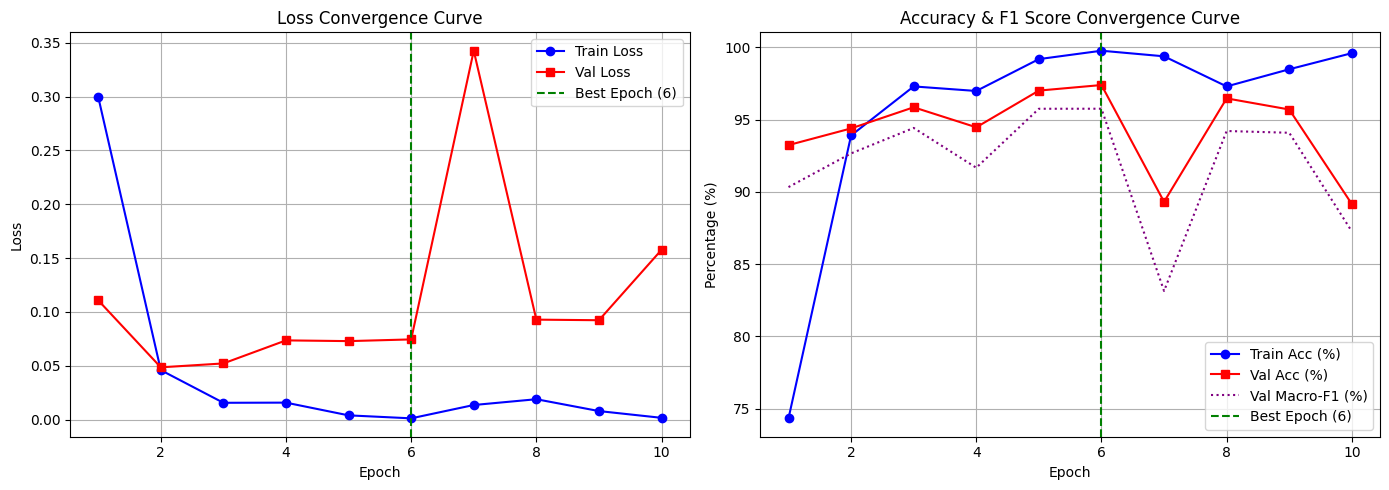


 THÔNG TIN MÔ HÌNH TỐT NHẤT (Đạt được ở Epoch 6)

[Báo Cáo Chi Tiết Trên Tập Test (Unseen Data)]
              precision    recall  f1-score   support

       Aorta     0.9773    0.9773    0.9773       132
       Flows     0.9498    0.9952    0.9720       209
       Other     0.9926    0.9657    0.9790       554
      V sign     0.9907    0.9907    0.9907       323
      X sign     0.9351    1.0000    0.9664        72

    accuracy                         0.9798      1290
   macro avg     0.9691    0.9858    0.9771      1290
weighted avg     0.9804    0.9798    0.9799      1290



In [16]:
import cv2
import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score
from PIL import Image

# Hàm tiền xử lý ảnh
def preprocess_ultrasound_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    return img

# ==========================================
# PYTORCH DATASET & DATALOADER
# ==========================================
class UltrasoundDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'filepath']
        label = self.df.loc[idx, 'label_idx']
        
        img_np = preprocess_ultrasound_image(img_path)
        img_pil = Image.fromarray(img_np)
        
        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = transforms.ToTensor()(img_pil)
            
        return img_tensor, torch.tensor(label, dtype=torch.long)

transform_pipeline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(UltrasoundDataset(train_df, transform_pipeline), batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(UltrasoundDataset(val_df, transform_pipeline), batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(UltrasoundDataset(test_df, transform_pipeline), batch_size=32, shuffle=False, num_workers=2)

# ==========================================
# FOCAL LOSS & CLASS WEIGHTS
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_idx']),
    y=train_df['label_idx'].values
)
alpha = torch.tensor(class_weights, dtype=torch.float)

# ==========================================
# KHỞI TẠO MÔ HÌNH VÀ HUẤN LUYỆN
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang chạy trên thiết bị: {device}\n")

model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
model = model.to(device)

criterion = FocalLoss(alpha=alpha.to(device), gamma=2)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

epochs = 15
patience = 4
best_val_f1 = 0.0
best_epoch = 0
early_stop_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

print(f"{'Epoch':<8} | {'Train Loss':<10} | {'Train Acc':<10} | {'Val Loss':<10} | {'Val Acc':<10} | {'Val Macro F1':<12} | Status")
print("-" * 80)

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
            
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    
    # --- VALIDATION ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    val_f1_macro = f1_score(all_labels, all_preds, average='macro')
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    history['val_f1'].append(val_f1_macro)
    
    # --- CHECKPOINT & EARLY STOPPING ---
    status = ""
    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        best_epoch = epoch + 1
        best_model_wts = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
        status = "[Saved Best]"
    else:
        early_stop_counter += 1
        status = f"Patience {early_stop_counter}/{patience}"
        
    print(f"{epoch+1:02d}/{epochs:02d}    | {epoch_train_loss:<10.4f} | {epoch_train_acc*100:<9.2f}% | {epoch_val_loss:<10.4f} | {epoch_val_acc*100:<9.2f}% | {val_f1_macro:<12.4f} | {status}")
    
    if early_stop_counter >= patience:
        print(f"\n=> EARLY STOPPING kích hoạt ở Epoch {epoch+1}.")
        break

# Tải lại trọng số tốt nhất
model.load_state_dict(best_model_wts)

# ==========================================
# VẼ ĐỒ THỊ SỰ HỘI TỤ
# ==========================================
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(range(1, len(history['val_loss'])+1), history['val_loss'], label='Val Loss', color='red', marker='s')
plt.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Loss Convergence Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['train_acc'])+1), [x*100 for x in history['train_acc']], label='Train Acc (%)', color='blue', marker='o')
plt.plot(range(1, len(history['val_acc'])+1), [x*100 for x in history['val_acc']], label='Val Acc (%)', color='red', marker='s')
plt.plot(range(1, len(history['val_f1'])+1), [x*100 for x in history['val_f1']], label='Val Macro-F1 (%)', color='purple', linestyle=':')
plt.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Accuracy & F1 Score Convergence Curve')
plt.xlabel('Epoch')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST
# ==========================================
print("\n" + "="*50)
print(f" THÔNG TIN MÔ HÌNH TỐT NHẤT (Đạt được ở Epoch {best_epoch})")
print("="*50)

model.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.numpy())

print("\n[Báo Cáo Chi Tiết Trên Tập Test (Unseen Data)]")
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))